# Market Response Models

In [1]:
from __future__ import division
from datetime import datetime, timedelta,date

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import plotly.offline as pyoff
import plotly.graph_objs as go

import sklearn
from sklearn.cluster import KMeans
import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report,confusion_matrix

In [2]:
def order_cluster(cluster_field_name, target_field_name,df,ascending):
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by=target_field_name,ascending=ascending).reset_index(drop=True)
    df_new['index'] = df_new.index
    df_final = pd.merge(df,df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final

In [3]:
df_data = pd.read_csv('../datasets/market_response_model_data.csv')

In [4]:
df_data.head(10)

,recency,history,used_discount,used_bogo,zip_code,is_referral,channel,offer,conversion
0,10,142.44,1,0,Surburban,0,Phone,Buy One Get One,0
1,6,329.08,1,1,Rural,1,Web,No Offer,0
2,7,180.65,0,1,Surburban,1,Web,Buy One Get One,0
3,9,675.83,1,0,Rural,1,Web,Discount,0
4,2,45.34,1,0,Urban,0,Web,Buy One Get One,0
5,6,134.83,0,1,Surburban,0,Phone,Buy One Get One,1
6,9,280.20,1,0,Surburban,1,Phone,Buy One Get One,0
7,9,46.42,0,1,Urban,0,Phone,Buy One Get One,0
8,9,675.07,1,1,Rural,1,Phone,Discount,0
9,10,32.84,0,1,Urban,1,Web,Buy One Get One,0


In [5]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   recency        64000 non-null  int64  
 1   history        64000 non-null  float64
 2   used_discount  64000 non-null  int64  
 3   used_bogo      64000 non-null  int64  
 4   zip_code       64000 non-null  object 
 5   is_referral    64000 non-null  int64  
 6   channel        64000 non-null  object 
 7   offer          64000 non-null  object 
 8   conversion     64000 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 4.4+ MB


In [6]:
df_data.conversion.mean()

0.14678125

In [7]:
def calc_uplift(df):
    #assigning 25$ to the average order value
    avg_order_value = 25
    
    #calculate conversions for each offer type
    base_conv = df[df.offer == 'No Offer']['conversion'].mean()
    disc_conv = df[df.offer == 'Discount']['conversion'].mean()
    bogo_conv = df[df.offer == 'Buy One Get One']['conversion'].mean()
    
    #calculate conversion uplift for discount and bogo
    disc_conv_uplift = disc_conv - base_conv
    bogo_conv_uplift = bogo_conv - base_conv
    
    #calculate order uplift
    disc_order_uplift = disc_conv_uplift * len(df[df.offer == 'Discount']['conversion'])
    bogo_order_uplift = bogo_conv_uplift * len(df[df.offer == 'Buy One Get One']['conversion'])
    
    #calculate revenue uplift
    disc_rev_uplift = disc_order_uplift * avg_order_value
    bogo_rev_uplift = bogo_order_uplift * avg_order_value
    
    
    print('Discount Conversion Uplift: {0}%'.format(np.round(disc_conv_uplift*100,2)))
    print('Discount Order Uplift: {0}'.format(np.round(disc_order_uplift,2)))
    print('Discount Revenue Uplift: ${0}\n'.format(np.round(disc_rev_uplift,2)))
          
    print('-------------- \n')

    print('BOGO Conversion Uplift: {0}%'.format(np.round(bogo_conv_uplift*100,2)))
    print('BOGO Order Uplift: {0}'.format(np.round(bogo_order_uplift,2)))
    print('BOGO Revenue Uplift: ${0}'.format(np.round(bogo_rev_uplift,2)))     

In [8]:
calc_uplift(df_data)

Discount Conversion Uplift: 7.66%
Discount Order Uplift: 1631.89
Discount Revenue Uplift: $40797.35

-------------- 

BOGO Conversion Uplift: 4.52%
BOGO Order Uplift: 967.4
BOGO Revenue Uplift: $24185.01


In [9]:
df_plot = df_data.groupby('recency').conversion.mean().reset_index()
plot_data = [
    go.Bar(
        x=df_plot['recency'],
        y=df_plot['conversion'],
    )
]

plot_layout = go.Layout(
        xaxis={"type": "category"},
        title='Recency vs Conversion',
        plot_bgcolor  = 'rgb(243,243,243)',
        paper_bgcolor  = 'rgb(243,243,243)',
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [10]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(df_data[['history']])
df_data['history_cluster'] = kmeans.predict(df_data[['history']])

In [11]:
df_data = order_cluster('history_cluster', 'history',df_data,True)

In [12]:
df_data.groupby('history_cluster').agg({'history':['mean','min','max'], 'conversion':['count', 'mean']})

history                   conversion          
                        mean      min      max      count      mean
history_cluster                                                    
0                  74.546732    29.99   162.15      32516  0.122647
1                 249.079807   162.16   366.91      17947  0.160863
2                 483.093780   366.93   652.19       8986  0.180058
3                 818.413641   652.23  1122.08       3667  0.194164
4                1422.038009  1122.34  3345.93        884  0.213801

In [13]:
df_plot = df_data.groupby('history_cluster').conversion.mean().reset_index()
plot_data = [
    go.Bar(
        x=df_plot['history_cluster'],
        y=df_plot['conversion'],
    )
]

plot_layout = go.Layout(
        xaxis={"type": "category"},
        title='History vs Conversion',
        plot_bgcolor  = 'rgb(243,243,243)',
        paper_bgcolor  = 'rgb(243,243,243)',
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [14]:
df_data.groupby(['used_discount','offer']).agg({'conversion':'mean'})

conversion
used_discount offer                      
0             Buy One Get One    0.169794
              Discount           0.166388
              No Offer           0.095808
1             Buy One Get One    0.136286
              Discount           0.196098
              No Offer           0.114533

In [15]:
df_data.groupby(['used_bogo','offer']).agg({'conversion':'mean'})

conversion
used_bogo offer                      
0         Buy One Get One    0.110892
          Discount           0.168968
          No Offer           0.099813
1         Buy One Get One    0.184530
          Discount           0.193974
          No Offer           0.111416

In [16]:
df_data.groupby(['used_discount','used_bogo','offer']).agg({'conversion':'mean'})

conversion
used_discount used_bogo offer                      
0             1         Buy One Get One    0.169794
                        Discount           0.166388
                        No Offer           0.095808
1             0         Buy One Get One    0.110892
                        Discount           0.168968
                        No Offer           0.099813
              1         Buy One Get One    0.251653
                        Discount           0.314993
                        No Offer           0.180549

In [17]:
df_plot = df_data.groupby('zip_code').conversion.mean().reset_index()
plot_data = [
    go.Bar(
        x=df_plot['zip_code'],
        y=df_plot['conversion'],
        marker=dict(
        color=['green', 'blue', 'orange'])
    )
]

plot_layout = go.Layout(
        xaxis={"type": "category"},
        title='Zip Code vs Conversion',
        plot_bgcolor  = 'rgb(243,243,243)',
        paper_bgcolor  = 'rgb(243,243,243)',
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [18]:
df_plot = df_data.groupby('is_referral').conversion.mean().reset_index()
plot_data = [
    go.Bar(
        x=df_plot['is_referral'],
        y=df_plot['conversion'],
        marker=dict(
        color=['green', 'blue', 'orange'])
    )
]

plot_layout = go.Layout(
        xaxis={"type": "category"},
        title='Referrals Conversion',
        plot_bgcolor  = 'rgb(243,243,243)',
        paper_bgcolor  = 'rgb(243,243,243)',
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [19]:
df_plot = df_data.groupby('channel').conversion.mean().reset_index()
plot_data = [
    go.Bar(
        x=df_plot['channel'],
        y=df_plot['conversion'],
        marker=dict(
        color=['green', 'blue', 'orange'])
    )
]

plot_layout = go.Layout(
        xaxis={"type": "category"},
        title='Channel vs Conversion',
        plot_bgcolor  = 'rgb(243,243,243)',
        paper_bgcolor  = 'rgb(243,243,243)',
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [20]:
df_plot = df_data.groupby('offer').conversion.mean().reset_index()
plot_data = [
    go.Bar(
        x=df_plot['offer'],
        y=df_plot['conversion'],
        marker=dict(
        color=['green', 'blue', 'orange'])
    )
]

plot_layout = go.Layout(
        xaxis={"type": "category"},
        title='Offer vs Conversion',
        plot_bgcolor  = 'rgb(243,243,243)',
        paper_bgcolor  = 'rgb(243,243,243)',
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [21]:
df_model = df_data.copy()
df_model = pd.get_dummies(df_model)

In [22]:
df_model.head()

,recency,history,used_discount,used_bogo,is_referral,conversion,history_cluster,zip_code_Rural,zip_code_Surburban,zip_code_Urban,channel_Multichannel,channel_Phone,channel_Web,offer_Buy One Get One,offer_Discount,offer_No Offer
0,10,142.44,1,0,0,0,0,False,True,False,False,True,False,True,False,False
1,2,45.34,1,0,0,0,0,False,False,True,False,False,True,True,False,False
2,6,134.83,0,1,0,1,0,False,True,False,False,True,False,True,False,False
3,9,46.42,0,1,0,0,0,False,False,True,False,True,False,True,False,False
4,10,32.84,0,1,1,0,0,False,False,True,False,False,True,True,False,False


In [23]:
df_model.conversion.mean()

0.14678125

In [24]:
#create feature set and labels
X = df_model.drop(['conversion'],axis=1)
y = df_model.conversion

In [25]:
X.columns

Index(['recency', 'history', 'used_discount', 'used_bogo', 'is_referral',
       'history_cluster', 'zip_code_Rural', 'zip_code_Surburban',
       'zip_code_Urban', 'channel_Multichannel', 'channel_Phone',
       'channel_Web', 'offer_Buy One Get One', 'offer_Discount',
       'offer_No Offer'],
      dtype='object')

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=56)

In [27]:
xgb_model = xgb.XGBClassifier().fit(X_train, y_train)

In [28]:
X_test['proba'] = xgb_model.predict_proba(X_test)[:,1] 

In [29]:
X_test.head(5)

,recency,history,used_discount,used_bogo,is_referral,history_cluster,zip_code_Rural,zip_code_Surburban,zip_code_Urban,channel_Multichannel,channel_Phone,channel_Web,offer_Buy One Get One,offer_Discount,offer_No Offer,proba
32277,3,77.34,1,0,1,0,False,False,True,False,True,False,False,False,True,0.061897
12824,10,39.49,0,1,1,0,False,False,True,False,True,False,False,False,True,0.004904
20159,11,29.99,1,0,1,0,False,True,False,False,False,True,True,False,False,0.047931
41575,2,345.36,0,1,0,1,False,False,True,False,False,True,False,True,False,0.287852
10736,9,41.75,0,1,0,0,False,True,False,False,True,False,False,False,True,0.009411


In [30]:
X_test.proba.mean()

0.14693312

In [31]:
y_test.mean()

0.14515625

In [32]:
X_test['conversion'] = y_test

In [33]:
X_test[X_test['offer_Buy One Get One'] == 1].conversion.mean()

0.14911048689138576

In [34]:
X_test[X_test['offer_Buy One Get One'] == 1].proba.mean()

0.1540882

In [35]:
X_test[X_test['offer_Discount'] == 1].conversion.mean()

0.18321513002364065

In [36]:
X_test[X_test['offer_Discount'] == 1].proba.mean()

0.18144396

In [37]:
X_test[X_test['offer_No Offer'] == 1].conversion.mean()

0.1037691949744067

In [38]:
X_test[X_test['offer_No Offer'] == 1].proba.mean()

0.10585649

In [39]:
real_disc_uptick = int(len(X_test)*(X_test[X_test['offer_Discount'] == 1].conversion.mean() - X_test[X_test['offer_No Offer'] == 1].conversion.mean()))

pred_disc_uptick = int(len(X_test)*(X_test[X_test['offer_Discount'] == 1].proba.mean() - X_test[X_test['offer_No Offer'] == 1].proba.mean()))



In [40]:
print('Real Discount Uptick - Order: {}, Revenue: {}'.format(real_disc_uptick, real_disc_uptick*25))
print('Predicted Discount Uptick - Order: {}, Revenue: {}'.format(pred_disc_uptick, pred_disc_uptick*25))

Real Discount Uptick - Order: 1016, Revenue: 25400
Predicted Discount Uptick - Order: 967, Revenue: 24175


In [41]:
real_bogo_uptick = int(len(X_test)*(X_test[X_test['offer_Buy One Get One'] == 1].conversion.mean() - X_test[X_test['offer_No Offer'] == 1].conversion.mean()))

pred_bogo_uptick = int(len(X_test)*(X_test[X_test['offer_Buy One Get One'] == 1].proba.mean() - X_test[X_test['offer_No Offer'] == 1].proba.mean()))



In [42]:
print('Real Discount Uptick - Order: {}, Revenue: {}'.format(real_bogo_uptick, real_bogo_uptick*25))
print('Predicted Discount Uptick - Order: {}, Revenue: {}'.format(pred_bogo_uptick, pred_bogo_uptick*25))

Real Discount Uptick - Order: 580, Revenue: 14500
Predicted Discount Uptick - Order: 617, Revenue: 15425


### Email Frequency Response Curve
Understanding diminishing returns in email marketing

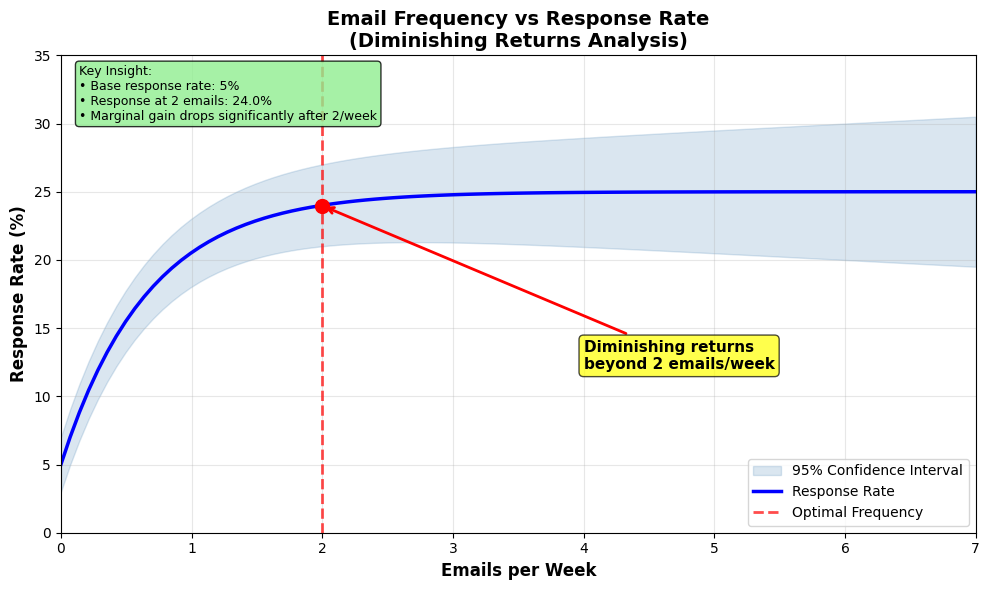

In [43]:
# Email Frequency Response Curve - Simulated data showing diminishing returns
import numpy as np
import matplotlib.pyplot as plt

# Generate data points for email frequency (0 to 7 emails per week)
emails_per_week = np.linspace(0, 7, 100)

# Response rate follows a logarithmic curve (diminishing returns)
# Starts at ~5% base rate, peaks around 25% at saturation
base_rate = 5
max_rate = 25
k = 1.5  # Controls steepness of curve

response_rate = base_rate + (max_rate - base_rate) * (1 - np.exp(-k * emails_per_week))

# Add confidence interval bands
ci_upper = response_rate + 2 + 0.5 * emails_per_week
ci_lower = response_rate - 2 - 0.5 * emails_per_week
ci_lower = np.maximum(ci_lower, 0)  # Ensure lower bound doesn't go negative

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot confidence interval
ax.fill_between(emails_per_week, ci_lower, ci_upper, alpha=0.2, color='steelblue', label='95% Confidence Interval')

# Plot main response curve
ax.plot(emails_per_week, response_rate, 'b-', linewidth=2.5, label='Response Rate')

# Add vertical line at x=2 marking the plateau point
ax.axvline(x=2, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Optimal Frequency')

# Add annotation for diminishing returns
ax.annotate('Diminishing returns\nbeyond 2 emails/week', 
            xy=(2, response_rate[np.argmin(np.abs(emails_per_week - 2))]),
            xytext=(4, 12),
            fontsize=11,
            fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Mark the optimal point
optimal_idx = np.argmin(np.abs(emails_per_week - 2))
ax.scatter([2], [response_rate[optimal_idx]], color='red', s=100, zorder=5)

# Formatting
ax.set_xlabel('Emails per Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Response Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Email Frequency vs Response Rate\n(Diminishing Returns Analysis)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 7)
ax.set_ylim(0, 35)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

# Add insight text box
insight_text = f'Key Insight:\n• Base response rate: {base_rate}%\n• Response at 2 emails: {response_rate[optimal_idx]:.1f}%\n• Marginal gain drops significantly after 2/week'
ax.text(0.02, 0.98, insight_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.show()